# Homework 6

# Wind-driven Circulation Model

## Comparison Between Sverdrup, Stommel and Munk Models
:::{attention} Theoretical Comparison (1.5 pts)
Describe the differences between the Sverdrup, Stommel, and Munk models.
Comment on the key physical insights regarding the wind-driven circulation that
are afforded by each model.
:::

The difference boils down to the friction handling. All three equations has the general form:
$$
\text{friction term} + \beta \partial_x \psi = F_\tau(x,y)
$$
- Sverdrup negelected the friction term completely by assuming $|r\zeta|<<|\beta v|$, the vorticity equation hence becomes:
$$
\beta \partial_x \psi = \mathrm{curl_z}(\tau_T)
$$
This is also known as the **Sverdrup balance**, which states that wind stress and the $\beta$ effect balance each other. While it accurately describes the interior of the ocean, it cannot satisfy the boundary condition of "no flow" at the western coast. It predicts water moving south, but provides no mechanism for it to return north.
- **Stommel** assumes linear drag $r\nabla^2 \psi$. The key insight is that Westward Intensification. Stommel discovered that because the Coriolis parameter $f$ varies with latitude ($\beta \neq 0$), the physics are not symmetric.On the eastern side, friction and the wind curl work against each other, leading to broad, slow flow.On the western side, friction and the $\beta$-effect reinforce each other, necessitating a narrow, extremely fast "jet" to return the water northward.
- **Munk** assumes harmonic visocity $\nu \nabla^4 \psi$. Munk used a more realistic representation of friction—internal friction between layers of water moving at different speeds—modeled using a Laplacian operator $\nabla^4 \psi$. This model successfully linked the broad wind-driven interior (Sverdrup) with a mathematically sophisticated western boundary (Stommel-like but more refined).


## Deriving relative vorticity equation from frictionaless horizontal momentum equation 

I'll use the vector form and take curl on both side instead of using cross-differentiation on component-wise equation to expose more physical intuition. Starting from the frictionaless horizontal momentum equation:
$$
D_t\mathbf{u}+f\times \mathbf{u}=\frac{1}{\rho}\nabla p
$$
Take the curl on both side:
$$
\nabla\times (D_t\mathbf{u})+\nabla \times (f\times \mathbf{u})=0
$$
where the R.H.S vanished since gradient is curl-free. 

##### Computing $\nabla \times (D_t \mathbf{u})$ 
$$
\nabla \times (\partial_t \mathbf{u} + (\mathbf{u}\cdot \nabla)\mathbf{u}) &=\nabla \times (\partial_t \mathbf u) + \nabla \times ((\mathbf{u}\cdot \nabla)\mathbf{u})
$$
Recall that:
:::{prf:theorem} Curl of Advection
For a general velocity field $\mathbf{u}$:
$$
\nabla \times [(\mathbf{u} \cdot \nabla)\mathbf{u}] = (\mathbf{u} \cdot \nabla)\zeta - (\zeta \cdot \nabla)\mathbf{u} + \zeta(\nabla\cdot\mathbf{u})
$$
where $\zeta=\nabla \times \mathbf{u}$
:::
Therefore 
$$
\nabla \times (\partial_t \mathbf{u} + (\mathbf{u}\cdot \nabla)\mathbf{u}) &= \nabla \times (\partial_t \mathbf u) + (\mathbf{u} \cdot\nabla)\zeta - (\zeta \cdot \nabla)\mathbf{u} + \zeta(\nabla\cdot\mathbf{u})
$$
The component-wise time derivative commutes with the curl operator $\nabla \times$. Applying to 2D flow (no $z$-dependence, $w=0$), the vortex stretching term vanishes: $(\zeta\cdot\nabla)\mathbf{u} = \zeta\,\partial_z\mathbf{u} = 0$. Hence:
$$
[\nabla \times (D_t \mathbf{u})]_z &= \partial_t \zeta + (\mathbf{u} \cdot\nabla)\zeta + \zeta\left(\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}\right) \\
&= D_t \zeta  + \zeta\left(\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}\right)
$$


##### Computing $\nabla \times (f\times \mathbf{u})$ 

Use the vector identity for curl of a cross product:
$$
\nabla \times (\mathbf{A} \times \mathbf{B}) = \mathbf{A}(\nabla \cdot \mathbf{B}) - \mathbf{B}(\nabla \cdot \mathbf{A}) + (\mathbf{B} \cdot \nabla)\mathbf{A} - (\mathbf{A} \cdot \nabla)\mathbf{B}
$$
With $\mathbf{A} = f\hat{k}$ and $\mathbf{B} = \mathbf{u}$:
$$
\nabla \times (f\hat{k} \times \mathbf{u}) = f\hat{k}(\nabla \cdot \mathbf{u}) - \mathbf{u}\underbrace{(\nabla \cdot f\hat{k})}_{=\,\partial_z f\,=\,0} + (\mathbf{u} \cdot \nabla)(f\hat{k}) - \underbrace{(f\hat{k} \cdot \nabla)\mathbf{u}}_{=\,f\partial_z\mathbf{u}\,=\,0\text{ (2D)}}
$$
Evaluating the remaining terms ($f=f(y)$ only):
- $(\mathbf{u} \cdot \nabla)(f\hat{k}) = v\,\partial_y f\,\hat{k} = \beta v\,\hat{k}$

Taking the vertical component with $\nabla\cdot\mathbf{u} = \frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}$ in 2D:
$$
[\nabla \times (f\hat{k} \times \mathbf{u})]_z = f\left(\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}\right) + \beta v
$$

##### Combining Both Terms

Substituting back into $\nabla \times (D_t\mathbf{u}) + \nabla \times (f\hat{k} \times \mathbf{u}) = 0$ and taking the vertical component:
$$
D_t \zeta + \zeta\left(\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}\right) + f\left(\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}\right) + \beta v = 0
$$
$$
D_t \zeta + (\zeta+f)\left(\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}\right) + \beta v = 0
$$
Since $D_t f = \mathbf{u}\cdot\nabla f = v\,\partial_y f = \beta v$, we have $D_t\zeta + \beta v = D_t(\zeta + f)$:
$$
\boxed{\frac{D}{Dt}(\zeta + f) + (\zeta + f)\left(\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}\right) = 0}
$$

##### Depth-integrated Continuity Equation

Integrating the continuity equation $\nabla\cdot\mathbf{U}=0$ vertically from the bottom $b$ to the surface $b+H$:
$$
\left(\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}\right)\int_b^{b+H} dz + w\Big|_b^{b+H} = 0
$$
Since $u,v$ are barotropic (independent of $z$), the integral gives $H$:
$$
\left(\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}\right)H + w(b+H) - w(b) = 0
$$
The kinematic boundary conditions (flow must follow the surface and the bottom) give:
$$
w(b+H) = \frac{\partial(b+H)}{\partial t} + u\frac{\partial(b+H)}{\partial x} + v\frac{\partial(b+H)}{\partial y}, \qquad
w(b) = u\frac{\partial b}{\partial x} + v\frac{\partial b}{\partial y}
$$
where $\partial b/\partial t = 0$ (rigid bottom). Taking the difference:
$$
w(b+H) - w(b) = \frac{\partial H}{\partial t} + u\frac{\partial H}{\partial x} + v\frac{\partial H}{\partial y} = \frac{DH}{Dt}
$$
Substituting back and dividing by $H$:
$$
\boxed{\left(\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}\right) + \frac{1}{H}\frac{DH}{Dt} = 0}
$$

##### Conservation of Shallow-Water Potential Vorticity

The continuity equation gives us:
$$
\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = -\frac{1}{H}\frac{DH}{Dt}
$$
Substituting into the absolute vorticity equation:
$$
\frac{D}{Dt}(\zeta + f) - \frac{(\zeta+f)}{H}\frac{DH}{Dt} = 0
$$
Dividing by $H$:
$$
\frac{1}{H}\frac{D(\zeta+f)}{Dt} - \frac{(\zeta+f)}{H^2}\frac{DH}{Dt} = \frac{D}{Dt}\!\left(\frac{\zeta+f}{H}\right) = 0
$$
$$
\boxed{\frac{D}{Dt}\!\left(\frac{\zeta+f}{H}\right) = 0}
$$
The quantity $q = \dfrac{\zeta+f}{H}$ is the **shallow-water potential vorticity**, and it is conserved following the flow. Physically, if a fluid column is stretched ($H$ increases), $\zeta$ must increase to keep $q$ constant — this is the vortex stretching mechanism.

## Sensitivity Analysis

:::{attention} Sensitivity Analysis (1 pt)
The solutions of these models are sensitive to the friction
coefficients. Investigate the Stommel and Munk cases separately by varying the friction
coefficient in the range of 1/8x and 8x of the default values. Plot the sensitivity of the
circulation strength to the friction changes. Briefly discuss the physical implications of
your results.
:::

### Stommel's Model

In [30]:
### classical cases ###
import sys
sys.path.append('../../../')
import numpy as np
import xarray as xr
from xinvert import invert_Stommel, cal_flow
import matplotlib as plt

In [31]:
def solve_stommel_beta(xnum, ynum, Lx, Ly, R, depth, beta, F):
    xdef = xr.DataArray(np.linspace(0, Lx, xnum), dims='xdef', coords={'xdef':np.linspace(0, Lx, xnum)})
    ydef = xr.DataArray(np.linspace(0, Ly, ynum), dims='ydef', coords={'ydef':np.linspace(0, Ly, ynum)})

    ygrid, xgrid = xr.broadcast(ydef, xdef)

    #wind stress(only have zonal component)
    tau_ideal = xr.DataArray(-F * np.cos(np.pi * ygrid / Ly), dims=['ydef','xdef'], coords={'ydef':ydef, 'xdef':xdef})

    # finite difference for curl
    curl_tau = - tau_ideal.differentiate('ydef')

    iParams = {
        'BCs'      : ['fixed', 'fixed'],
        'mxLoop'   : 3000,
        'tolerance': 1e-8,
        'optArg'   : 1.9,
        'undef'    : np.nan,
    }
    
    mParams2 = {'beta': beta, 'R': R, 'D': depth}

    S = invert_Stommel(curl_tau, dims=['ydef','xdef'], coords='cartesian', mParams=mParams2, iParams=iParams)

    u, v = cal_flow(S, dims=['ydef','xdef'], coords='cartesian')
    
    return u, v

In [ ]:
params = {
    'xnum' : 201,
    'ynum' : 151,
    'Lx' : 1e7, # 10,000 km
    'Ly' : 2 * np.pi * 1e6, # 6249 km
    'depth' : 200, # fluid depth 200
    'beta' : 1.8e-11,
    'F' : 0.3
}
u, v = solve_stommel_beta(**params, R=0.0008)


### Monk's Model

A quick look at miniUFO's codebase we can find that he defined $A4$ for the coefficient of the harmonic viscosity term. We hence write a function using that as an input. Also they seem to only provide a Stommel-Monk API instead of a pure monk model, however, we can recover Monk's model by setting $r=0$.


In [32]:
from xinvert import invert_StommelMunk

def solve_monk_beta(xnum, ynum, Lx, Ly, F, depth, beta, nu):
    xdef = xr.DataArray(np.linspace(0, Lx, xnum), dims='xdef', coords={'xdef':np.linspace(0, Lx, xnum)})
    ydef = xr.DataArray(np.linspace(0, Ly, ynum), dims='ydef', coords={'ydef':np.linspace(0, Ly, ynum)})

    ygrid, xgrid = xr.broadcast(ydef, xdef)

    tau_ideal = xr.DataArray(-F * np.cos(np.pi * ygrid / Ly), dims=['ydef','xdef'],
                             coords={'ydef':ydef, 'xdef':xdef})
    curl_tau = -tau_ideal.differentiate('ydef')

    iParams = {
        'BCs'      : ['fixed', 'fixed'],
        'mxLoop'   : 10000,
        'tolerance': 1e-8,
        'optArg'   : 1.5,
    }
    mParams = {'R': 0.0, 'D': depth, 'A4': nu, 'beta': beta}

    h2 = invert_StommelMunk(curl_tau, dims=['ydef','xdef'], coords='cartesian',
                            mParams=mParams, iParams=iParams)
    return cal_flow(h2, dims=['ydef','xdef'], coords='cartesian')

In [33]:
params = {
    'xnum' : 201,
    'ynum' : 151,
    'Lx' : 1e7, # 10,000 km
    'Ly' : 2 * np.pi * 1e6, # 6249 km
    'depth' : 200, # fluid depth 200
    'beta' : 1.8e-11,
    'F' : 0.3
}

u, v = solve_monk_beta(**params, nu=1e4)

{} loops 4000 and tolerance is 1.657930e-04


#### Circulation Strength

In order to study the sensitivty of circulation strength to perturbation in frictional coefficient, we define the circulation strength as the magnitude of the curl field. 
$$
|\nabla \times \mathbf{u}| = \sqrt{(\partial_y w - \partial_z v)^2 + (\partial_z u - \partial_x w)^2 + (\partial_x v - \partial_y u)^2}
$$

In [34]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_curl_mag(u, v, ax=None, title=None, vmin=None, vmax=None):
    curl = v.differentiate('xdef') - u.differentiate('ydef')
    curl = curl.isel(xdef=slice(2, -2), ydef=slice(2, -2))
    mag  = np.abs(curl)

    if vmin is None:
        vmin = float(mag.where(mag > 0).min())
    if vmax is None:
        vmax = float(mag.max())

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 5))

    mag.plot(ax=ax, cmap='plasma', norm=LogNorm(vmin=vmin, vmax=vmax),
             add_colorbar=True, cbar_kwargs={'label': r'$|\zeta|$ (s$^{-1}$)'})
    ax.set_title(title or r'$|\partial v/\partial x - \partial u/\partial y|$')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')

    if standalone:
        plt.tight_layout()
        plt.show()


def plot_curl_mag_sensitivity(params, friction_values, model='stommel'):
    """
    model : 'stommel' — varies R (linear drag)
            'munk'    — varies nu (biharmonic viscosity A4)
    """
    solvers = {
        'stommel': lambda fric: solve_stommel_beta(**params, R=fric),
        'munk':    lambda fric: solve_monk_beta(**params, nu=fric),
    }
    labels = {
        'stommel': lambda fric: f'R = {fric:.4g}',
        'munk':    lambda fric: f'A4 = {fric:.4g}',
    }
    if model not in solvers:
        raise ValueError(f"model must be 'stommel' or 'munk', got '{model}'")

    solve = solvers[model]
    label = labels[model]

    n     = len(friction_values)
    ncols = 2
    nrows = (n + ncols - 1) // ncols

    mags, solutions = [], []
    for fric in friction_values:
        print(f'Solving {label(fric)} ...')
        u_i, v_i = solve(fric)
        solutions.append((u_i, v_i))
        curl = v_i.differentiate('xdef') - u_i.differentiate('ydef')
        curl = curl.isel(xdef=slice(2, -2), ydef=slice(2, -2))
        mags.append(np.abs(curl))

    global_vmin = min(float(m.where(m > 0).min()) for m in mags)
    global_vmax = max(float(m.max())              for m in mags)

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 5 * nrows))
    axes = axes.flatten()

    for i, (fric, (u_i, v_i)) in enumerate(zip(friction_values, solutions)):
        plot_curl_mag(u_i, v_i, ax=axes[i], title=label(fric),
                      vmin=global_vmin, vmax=global_vmax)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    model_name = 'Stommel' if model == 'stommel' else 'Munk'
    fig.suptitle(f'{model_name} — curl magnitude friction sensitivity', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

First run on Stommel's model:

Solving R = 0.0004 ...
{} loops  590 and tolerance is 1.448650e-09
Solving R = 0.002 ...
{} loops  736 and tolerance is 9.968284e-09
Solving R = 0.0036 ...
{} loops 1235 and tolerance is 9.965702e-09
Solving R = 0.0052 ...
{} loops 1506 and tolerance is 9.956110e-09


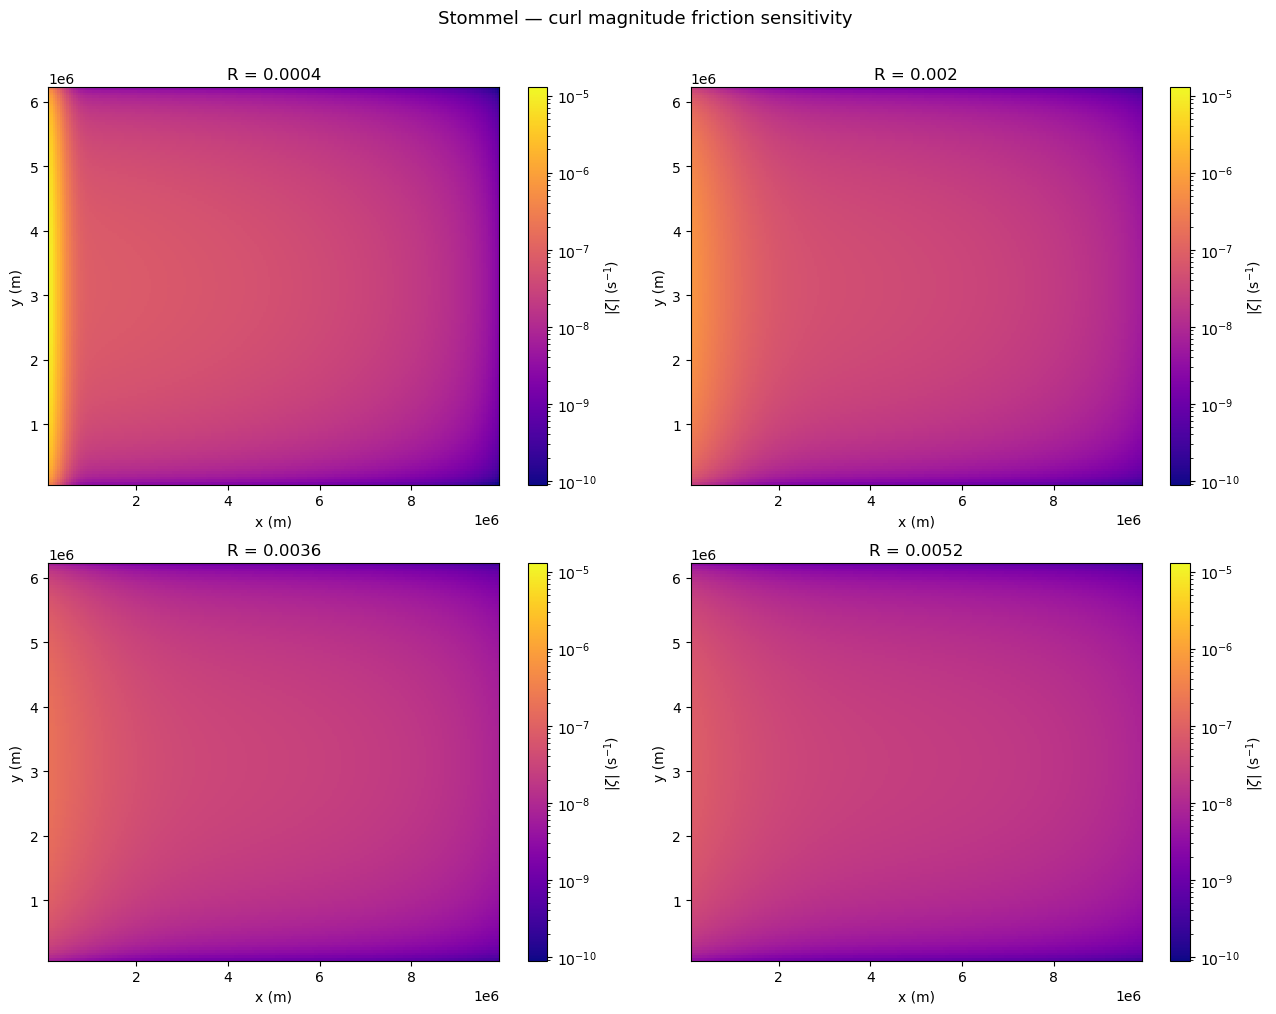

In [35]:
R_default = 0.0004
R_values  = R_default * np.arange(1, 16, 4)
plot_curl_mag_sensitivity(params, R_values, model='stommel')

Recall in stommel's model:
$$
r\nabla^2 \psi + \beta \partial_x \psi = F_\tau(x,y)
$$

It is clear that higher friction coefficient result's in less circulation strength. The reason follows:

:::{note} $r$ and circulation strength
At the western boundary, we have the following balance[^q1]:
$$
r\nabla^2 \psi \approx -\beta \partial_x \psi
$$
Noting that lapalacian of the *stream function* is just the relative vorticiyt $\zeta$, we have that 
$$
\frac{\partial}{\partial r} \zeta = - \frac{\beta \partial_x \psi}{r^2} 
$$
Hence $\zeta$ increases when $r$ decreases, and the trend is even stronger if $r$ is small.
:::




[^q1]: I read it from the vallis textbook, not exactly sure why, need to find out

Next repeat for Monk's model:


Solving A4 = 1250 ...
{} loops 2257 and tolerance is 5.477516e-09
Solving A4 = 5000 ...
{} loops 4000 and tolerance is 2.021915e-06
Solving A4 = 2e+04 ...
{} loops 4000 and tolerance is 2.127621e-04
Solving A4 = 8e+04 ...
{} loops 4000 and tolerance is 2.407939e-04


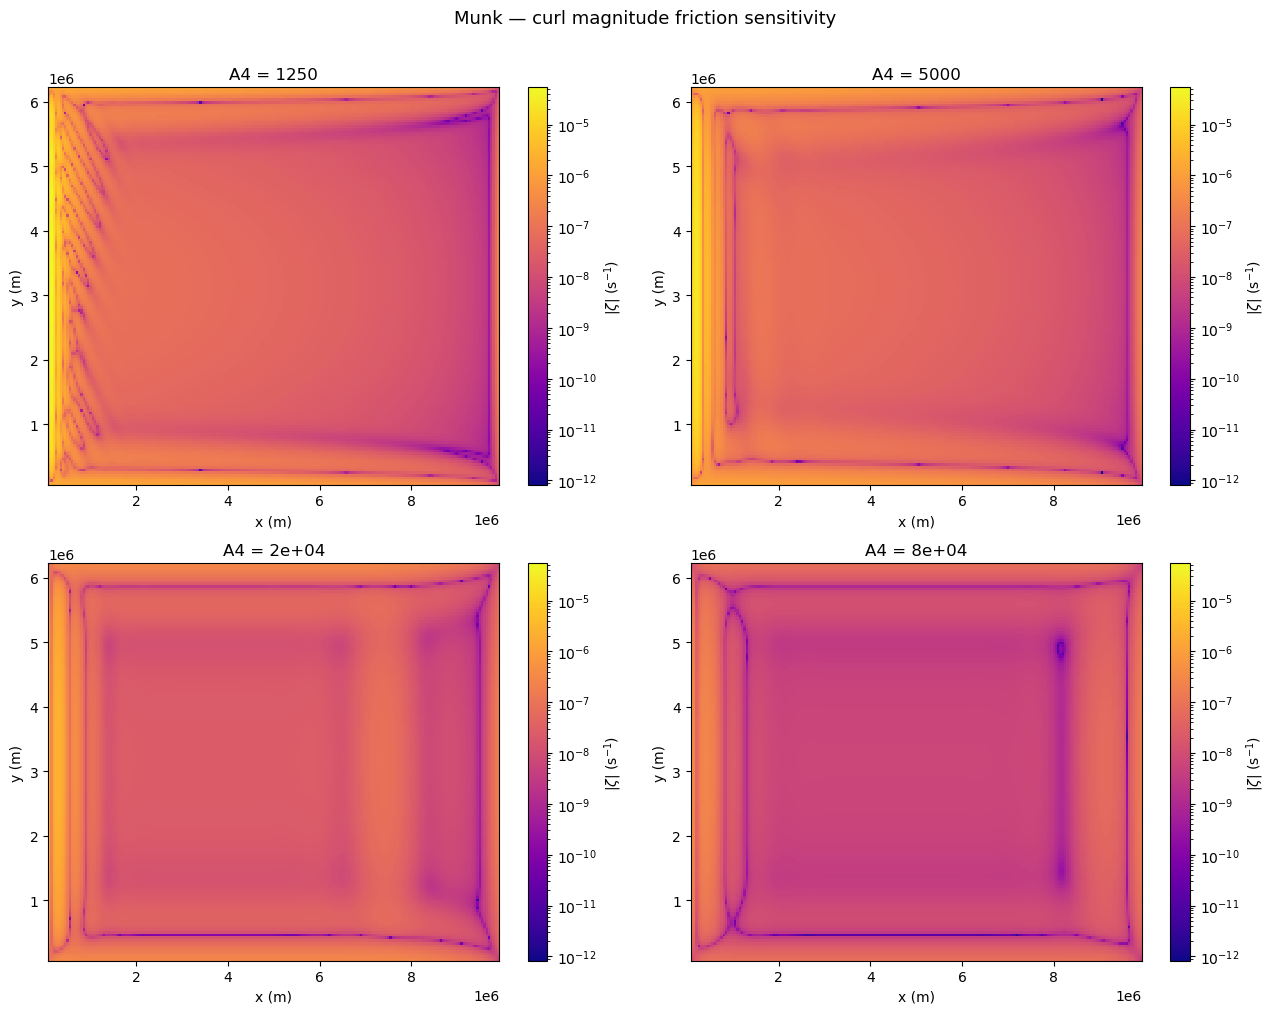

In [39]:
nu_default = 1e4
# 1/8x, 1/2x, 2x, 8x of default — log-spaced to properly cover the sensitivity range
nu_values  = nu_default * np.array([1/8, 1/2, 2, 8])
plot_curl_mag_sensitivity(params, nu_values, model='munk')

The Monk Solver has numerical issues hence the numerical artifact we see in the plot. However we still can note that:
  - $\nu=1250$: The Munk layer is thinner than the grid spacing → numerical oscillations on the western boundary. Not
  physical — just resolution breakdown.
  - $\nu=5000$: First clean solution. Sharp yellow stripe on the western boundary = narrow, intense vorticity
  concentrated in a thin WBC. Interior is near-Sverdrup balance (low $|\zeta|$).
  - $\nu=20000$: Boundary layer is visibly wider and peak $|\zeta|$ has dropped — viscosity is diffusing vorticity
  laterally. Interior starts showing more structure.
  - $\nu=80000$: Layer is very broad (~170 km). Note the anomalous circular blob in the upper-right interior — the
  solver likely didn't fully converge (the 4th-order system is harder to solve at high $\nu$).

**Key Contrast With Stommel:**
In Stommel, higher R uniformly damps  $|\zeta|$ everywhere. In Munk, higher $\nu$ redistributes
vorticity — the western boundary layer widens and weakens while the interior Sverdrup balance is largely
preserved. This is because biharmonic friction is a 4th-order operator that only activates where curvature is
large (boundary layers), unlike Stommel's bulk linear drag.


### Realistic Example With Stommel-Monk

:::{attention} Realistic Example
Investigate the real-world case with the SODA (Simple
Ocean Data Assimilation) data. Plot the solutions for January and July. Review concepts
and theories from earlier lectures, highlight and explain how the seasonal variations in the
wind fields drive the ocean circulation changes in your results.
:::

First solve the equation for the desired monts:

In [37]:
#%% real cases — January to July, pure matplotlib
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from xinvert import invert_StommelMunk, cal_flow

ds   = xr.open_dataset('Data/SODA_curl.nc')
curl = ds.curl

iParams = {
    'BCs'      : ['fixed', 'periodic'],
    'mxLoop'   : 4000,
    'tolerance': 1e-14,
    'optArg'   : 1.0,
    'undef'    : np.nan,
}
mParams = {'R': 1e-4, 'D': 100, 'A4': 3e3, 'beta': 1.8e-11, 'rho0': 1027}

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul']
levels = np.linspace(-80, 80, 33)
skip   = 3

cf_last = None
results = []
for i, month in enumerate(months):
    h   = invert_StommelMunk(curl[i], dims=['lat', 'lon'], mParams=mParams, iParams=iParams)
    results.append(h)
    

{} loops 4000 and tolerance is 5.033666e-05
{} loops 4000 and tolerance is 4.624757e-05
{} loops 4000 and tolerance is 4.694164e-05
{} loops 4000 and tolerance is 5.154027e-05
{} loops 4000 and tolerance is 5.673081e-05
{} loops 4000 and tolerance is 6.979964e-05
{} loops 4000 and tolerance is 6.182220e-05


Making sure the internal strucutre of our dataset:

In [ ]:
print(curl)

Now plot the result:

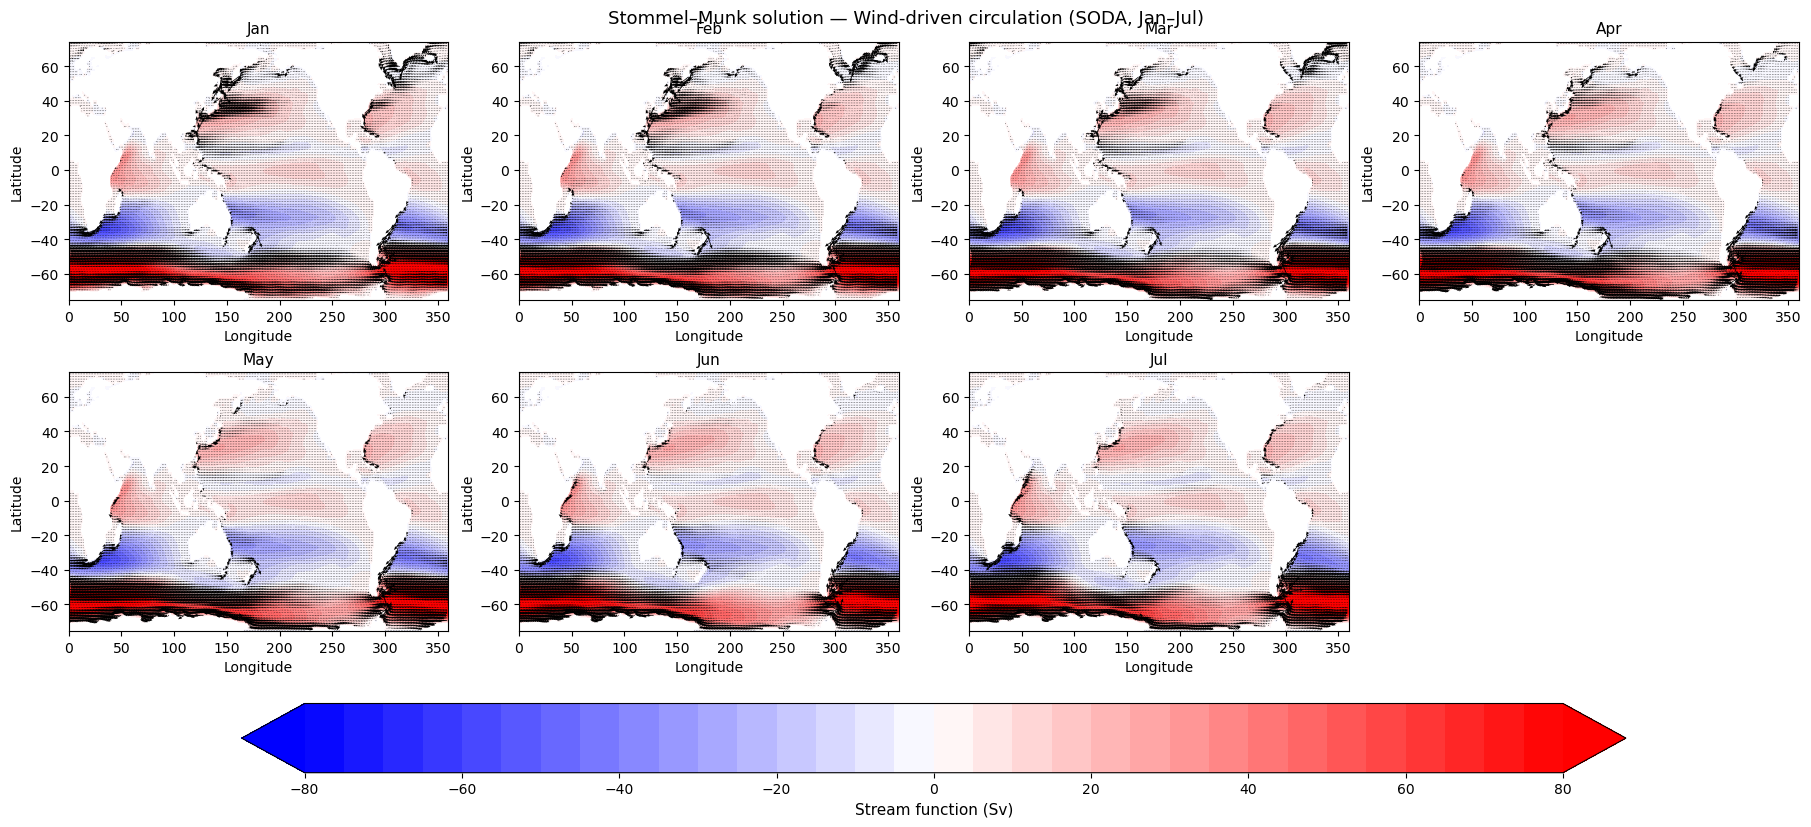

In [38]:

def plot_over_months(months, hs):
    assert len(months) == len(hs), "number of months not equal to number of solutions"
    
    fig, axes = plt.subplots(2,(len(months)+1)//2, figsize=(18, 8), constrained_layout=True)
    axes_flat = axes.flatten()
    
    for i, month in enumerate(months):
        u, v = cal_flow(hs[i], dims=['lat', 'lon'], BCs=['extend', 'periodic'])
        lat, lon = xr.broadcast(u.lat, u.lon)

        ax = axes_flat[i]

        cf = ax.contourf(lon.values, lat.values, h.values / 1e6 * 100,
                            levels=levels, cmap='bwr', extend='both')

        ax.quiver(lon.values[::skip, ::skip], lat.values[::skip, ::skip],
                    u.values[::skip, ::skip], v.values[::skip, ::skip],
                    scale=70, width=0.002, headwidth=4, headlength=5)
        
        ax.set_xlim([0, 360])
        ax.set_ylim([-75.25, 74.25])
        ax.set_title(month, fontsize=11)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        cf_last = cf

    axes_flat[-1].set_visible(False)

    cbar = fig.colorbar(cf_last, ax=axes_flat[:7], orientation='horizontal',
                        shrink=0.8, pad=0.04)
    cbar.set_label('Stream function (Sv)', fontsize=11)
    cbar.set_ticks(np.arange(-80, 81, 20))

    fig.suptitle('Stommel–Munk solution — Wind-driven circulation (SODA, Jan–Jul)',
                fontsize=13, y=1.01)
    plt.show()

plot_over_months(months, results)

We make some observations:

- At January, Febuarary and March, there are dark red/black shading indicating high stream function value at the subtropical gyres. This can be explained by the relatively stronger mid-latitude westerlies and tropical trade winds during these months. Conversely, during the summer, the gradients soften, corresponding to the relatively weaker mid-latitude westerlies and tropical trade winds.
  
- The ACC seems to have a "red core" through out Jan to April while it gradually diffuse out(lower value) during the south hemisphere winter. This is counter-intuitive but might be due to two reasons:
  1. Seasonal Lag; The wind stress is generally lower during southern hemisphere summer, the effect cumulate and manifest itself in May/June/July. 
  2. Shift of the southern hemisphere westerlies. During southern hemisphere winter the southern hemisphere westerlies tends to shift toward equator as the "thermal equator" migrates.

# ENSO
## Bjerknes feedback
:::{attention} Bjerknes feedback
The ENSO development depends on positive feedback. Describe
Bjerknes feedback for the El Nino years. The description should account for SST, wind,
and thermocline.
:::

We first describe the neutral condition:
1. Therocline is shallow in the east and deep in the west 
2. SST is low at east and high at west
(these are actually conveying the same message since upwelling brings cold water hence lower temperature)

The feedback contains the followsing cascade:

1. As the trade winds weaken, the Sea Surface Temperature (SST) gradient across the Pacific flattens. The "Warm Pool" in the west begins to slosh eastward.
2. Since the atmosphere is driven by the underlying heat, the reduction in the SST gradient further weakens the Walker Circulation. This creates a loop: weaker winds lead to warmer eastern waters, which in turn further weaken the winds.
3. When the westerly wind anomalies occur, they generate equatorial Kelvin waves that travel eastward.
4. These waves depress the thermocline in the Central and Eastern Pacific. This further increases the SST in the east by circumventing upwelling.

## Phase Locking By Oscillator Theory
:::{attention} Phase Locking
Consult the equation that describes the feedback process of the ENSO:

$$
\partial_t T = aT(t)-bT(t-\delta)-rT^3(t)
$$

Focus on the 2nd and 3rd terms and explain why the El Nino and La Nina tend to peak during
the wintertime of the Northern Hemisphere (phase locking).
:::

The second term $bT(t-\delta)$ which is the delayed negative feedback models the "memory" of the ocean. The delay is usally $6\sim 9$ months. Since perturbation likely occurs in spring/early summer(Due to the spring barrier, when air-sea coupling is weak, causing the system to be highly sensitve), the event would peak after $\delta$ units which arrives maximum amplitude right around $DJF$. 

The third term $rT^3(t)$ is the damping term. This term makes spring barrier special since it makes the systme less prune to perturbation. During other times around the year apart from the spring, air sea interaction is strong hence perturbation is generally weak. The damping term ensures event does not initate during these time.


## Climate Application 

:::{attention} Climate Application[0.75pt]
Predicting the ENSO can help predict the wintertime
climate variables of North America. Name two applications of such predictions and
recommend one way to convince users that your predictions are skillful and/or well-
grounded.
:::

*Application 1*: "Wind Drought" For Renewable Energy

Since El Nino tend to shift the pacific jet stream southward, this can cause the nothern part of the U.S and Canada to out of "wind flow" through out the winder possibly starving Renewable Energy Businesses. 

*Application 2*: Energy Management 

During an El Niño winter, the northern United States often experiences warmer-than-average temperatures, while the southern tier can be cooler. Sine heating is a significant source of energy consumption during the winter time, Power grid can utillise this information to program electricity supply accordingly to maximize efficiency. This in turn prevents price surge due to shortage or waste of resource otherwise. 

--- 
One way to convince users predictions are skillful is to show historically people have succesfully forecasted El Nino. Of course, one could argue profit-driven companies have the motivation to exaggerate the historical accuracy, however, by cross-validating the source of the information(i.e. the historical succes of ENSO prediction), it should appear reasonable that ENSO prediction remains grounded for future predictions. 




